In [1]:
import pandas as pd 
import re
import emoji 
from pathlib import Path 
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# Configuration des graphiques
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)
data_dir = Path('../data')
resume_dataset=pd.read_csv(data_dir/'interim/combined_resume_final.csv')
offer_dataset=pd.read_csv(data_dir/'interim/combined_offer_dataset.csv')


In [2]:
#Lecture et affichage Information dataframme
def read_data(data,column_name):
    print("\n __Aperçu des données :")
    print(data.head(3))
    # Afficher les informations sur le DataFrame
    print("\n __Informations sur les données :")
    print(data.info())
    print(" \n __Taille : \n",data.shape)
    print("\n __Information sur les Categories: \n",data[column_name].value_counts().reset_index())

### DATASET AVant PREPROCESSING

#### Lecture et affichage des donnees

In [3]:
resume_dataset.head()
read_data(resume_dataset,'Category')


 __Aperçu des données :
                        Category  \
0         Database Administrator   
1         Database Administrator   
2  Oracle Database Administrator   

                                              Resume  
0  Ability: Installation and Building Server, Run...  
1  Ability: database management systems administr...  
2  Ability: Over 4+ years of Experience as Archit...  

 __Informations sur les données :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12104 entries, 0 to 12103
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  12104 non-null  object
 1   Resume    12104 non-null  object
dtypes: object(2)
memory usage: 189.2+ KB
None
 
 __Taille : 
 (12104, 2)

 __Information sur les Categories: 
                                 Category  count
0                       Security_Analyst    861
1                     Software_Developer    783
2       Web_Developer,Software_Developer    648
3          

In [4]:
offer_dataset.head()
read_data(offer_dataset,'Job Title_Category')


 __Aperçu des données :
                              Job Title_Category  \
0                  Prompt Engineer and Librarian   
1             Social Sciences Librarian - 500421   
2  Collection Management Specialist, EBSCO Books   

                                     Job Description  
0  Anthropic’s mission is to create reliable, int...  
1  Social Sciences Librarian - 500421\n\nSUMMARY:...  
2  EBSCO Information Services (EIS) provides a co...  

 __Informations sur les données :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3339 entries, 0 to 3338
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Job Title_Category  3339 non-null   object
 1   Job Description     3339 non-null   object
dtypes: object(2)
memory usage: 52.3+ KB
None
 
 __Taille : 
 (3339, 2)

 __Information sur les Categories: 
                                      Job Title_Category  count
0                                       

#### Exploration des donnees

In [5]:
category_counts = resume_dataset['Category'].value_counts()
print(f"\nNombre de lignes dataset: {len(resume_dataset.index)}")
print(f"\nNombre de catégories : {len(category_counts.index)}")
print("\nListe des catégories :")
print(category_counts.index.sort_values())


Nombre de lignes dataset: 12104

Nombre de catégories : 220

Liste des catégories :
Index(['AEM Developer', 'Administrative Assistant', 'Advocate',
       'Android Application Developer', 'Android Developer',
       'Application Developer', 'Arts', 'Automation Testing',
       'Backend Developer', 'Blockchain',
       ...
       'Technical Consultant', 'Technical Project Manager', 'Testing',
       'UI Developer', 'UI Developer UI Developer UI Developer',
       'UI/ Front End Developer', 'Web Designing', 'Web Developer',
       'Web Developer Web Developer Web Developer',
       'Web_Developer,Software_Developer'],
      dtype='object', name='Category', length=220)


In [6]:
print(f"\nNombre de lignes dataset: {len(offer_dataset.index)}")


Nombre de lignes dataset: 3339


#####  ----Distribution des catégories (top 30)

/tmp/ipykernel_8085/1699642339.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.barplot(x=top_cats.values, y=top_cats.index, palette="viridis", ax=ax1)


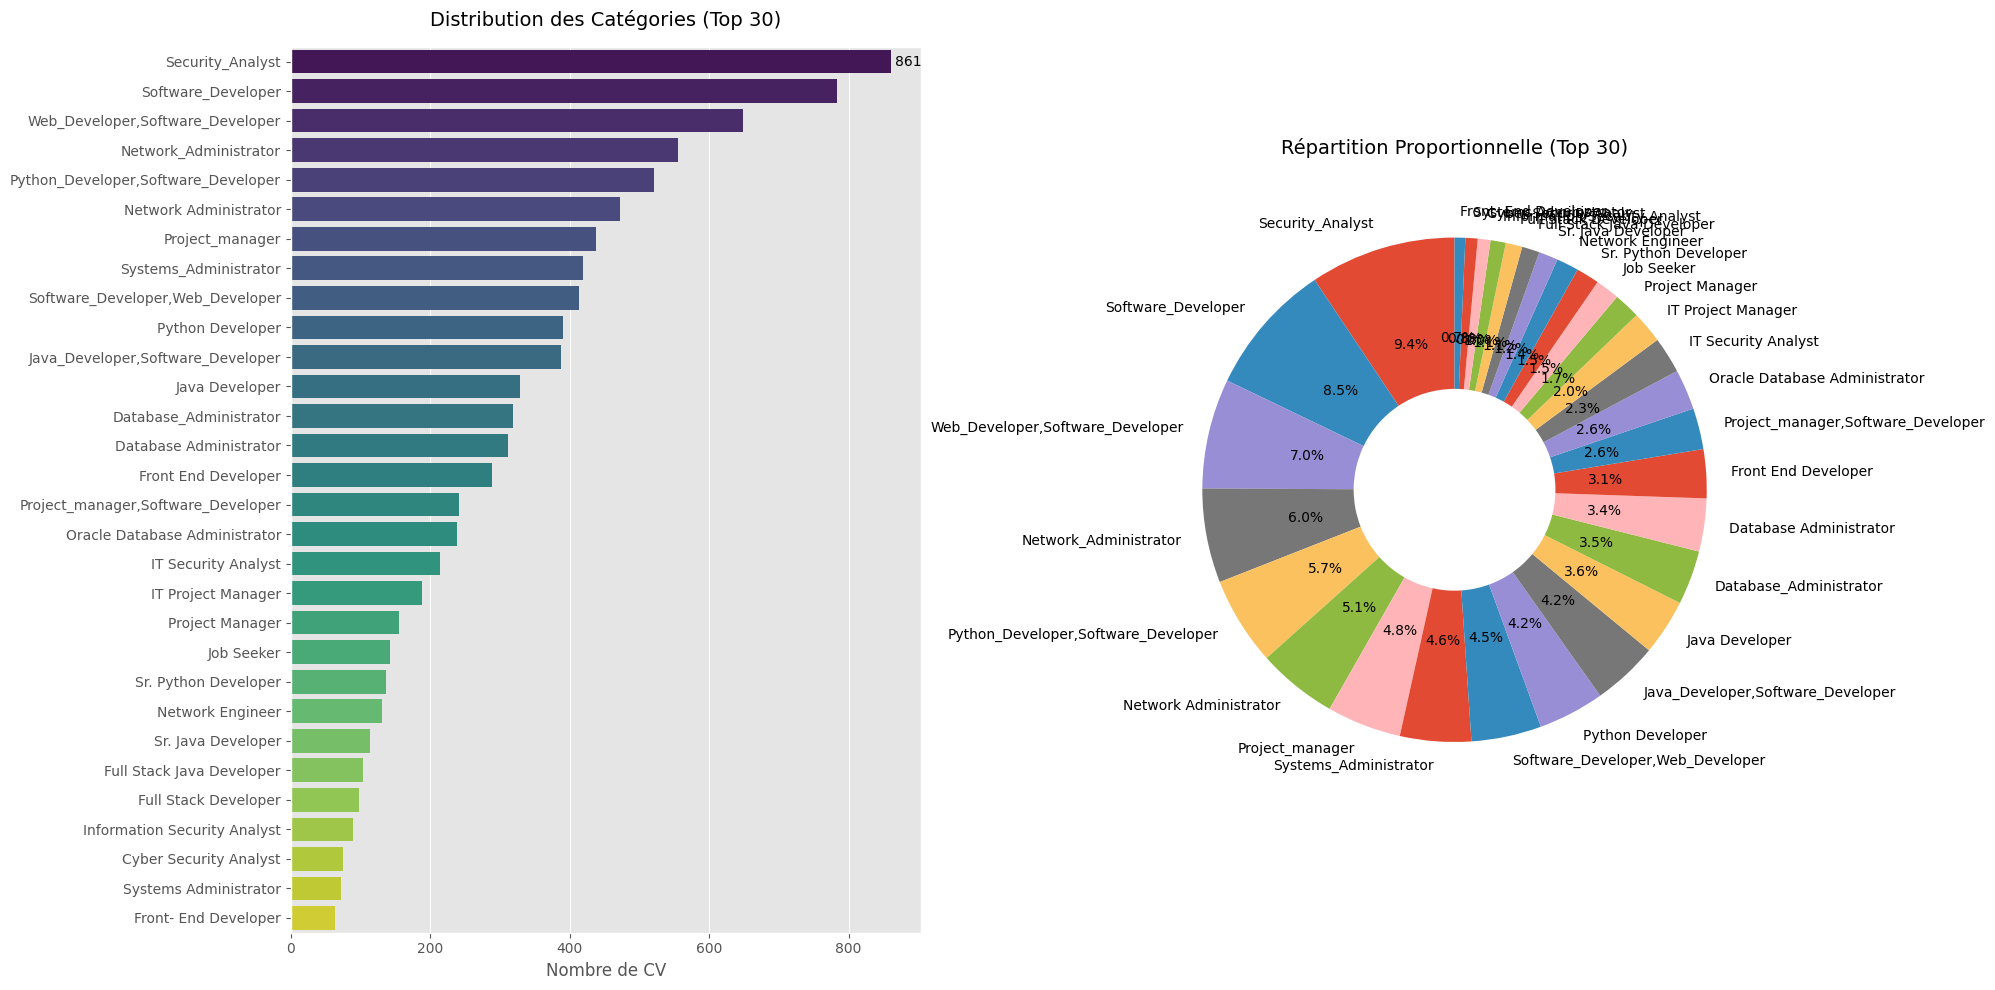

In [7]:
new__resume_dataset=resume_dataset.copy(deep=True)
def plot_category_distribution(data, column_name,top_n, figsize=(20, 10)):
    """
    Affiche la distribution des catégories sous forme de barplot et pie chart
    """
    plt.figure(figsize=figsize)
    grid = plt.GridSpec(1, 2, width_ratios=[1.5, 1.5])

    # 1. Barplot hiérarchique (Top 15)
    ax1 = plt.subplot(grid[0])
    top_cats = data[column_name].value_counts().nlargest(top_n)
    bar = sns.barplot(x=top_cats.values, y=top_cats.index, palette="viridis", ax=ax1)
    ax1.set_title('Distribution des Catégories (Top 30)', fontsize=14, pad=15)
    ax1.set_xlabel('Nombre de CV', fontsize=12)
    ax1.set_ylabel('')
    ax1.bar_label(bar.containers[0], fmt='%d', padding=3, fontsize=10)

    # 2. Pie Chart (Top 10)
    ax2 = plt.subplot(grid[1])
    top_10 = data[column_name].value_counts().nlargest(top_n)
    top_10.plot.pie(autopct='%1.1f%%', startangle=90, ax=ax2, 
                    wedgeprops={'width':0.6}, textprops={'fontsize':10})
    ax2.set_title('Répartition Proportionnelle (Top 30)', fontsize=14, pad=15)
    ax2.set_ylabel('')


    plt.tight_layout()
    plt.show()

plot_category_distribution(new__resume_dataset,'Category',30)

#####  ----Distribution de la longueur des CV par catégorie

/tmp/ipykernel_8085/9861235.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.barplot(x=mean_by_category.head(n_categories).values,


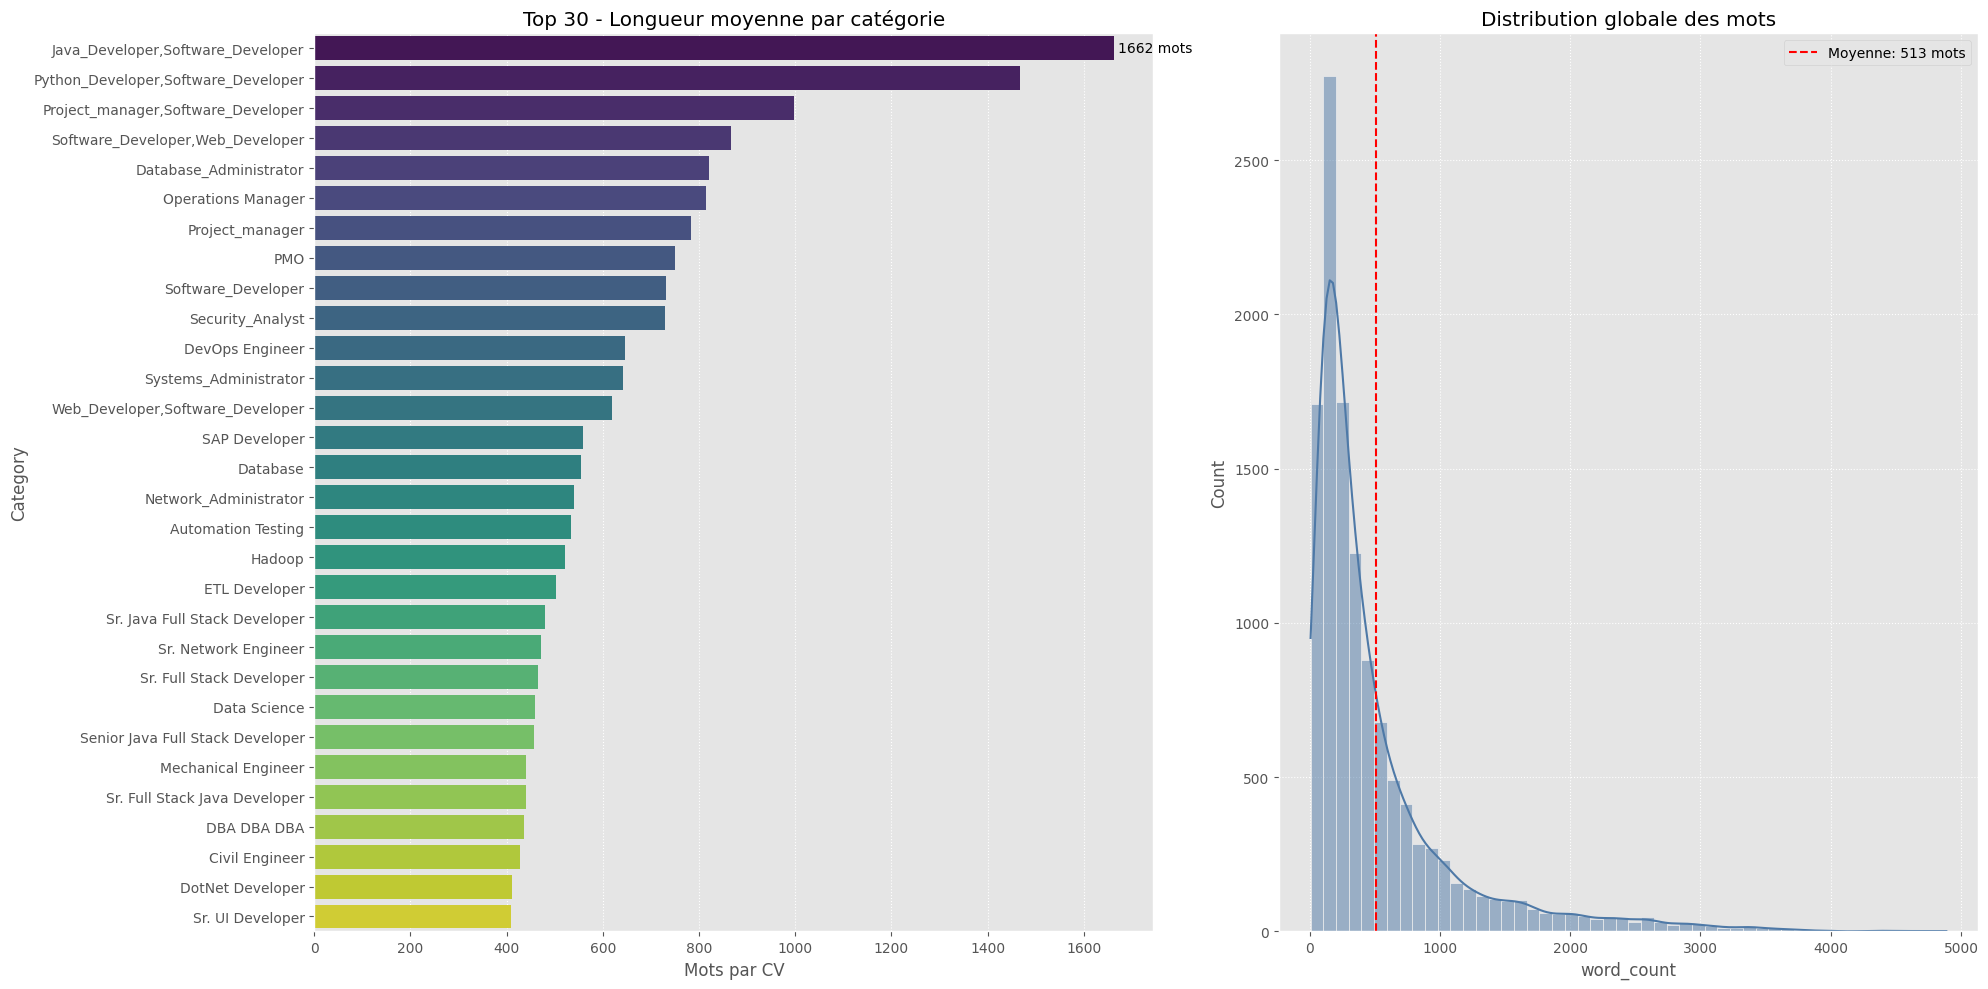

In [8]:
def plot_cv_length_analysis(df, n_categories=30, figsize=(20, 10)):
    """
    Analyse visuelle de la longueur des CV par mots
    """
    # Calcul des métriques
    df = df.copy()
    df['word_count'] = df['Resume'].apply(lambda x: len(x.split()))
    mean_by_category = df.groupby('Category')['word_count'].mean().sort_values(ascending=False)
    global_mean = df['word_count'].mean()
    
    # Création de la figure
    plt.figure(figsize=figsize)
    grid = plt.GridSpec(1, 2, width_ratios=[1.2, 1])
    
    # 1. Barplot des catégories les plus longues
    ax1 = plt.subplot(grid[0])
    bar = sns.barplot(x=mean_by_category.head(n_categories).values,
                     y=mean_by_category.head(n_categories).index,
                     palette="viridis")
    ax1.bar_label(bar.containers[0], fmt='%.0f mots', padding=3)
    ax1.set_title(f'Top {n_categories} - Longueur moyenne par catégorie')
    ax1.set_xlabel('Mots par CV')
    ax1.grid(axis='x', linestyle=':')
    
    # 2. Distribution globale
    ax2 = plt.subplot(grid[1])
    hist = sns.histplot(df['word_count'], bins=50, kde=True, color='#4e79a7')
    ax2.axvline(global_mean, color='red', linestyle='--', 
                label=f'Moyenne: {global_mean:.0f} mots')
    ax2.set_title('Distribution globale des mots')
    ax2.legend()
    ax2.grid(linestyle=':')
    
    plt.tight_layout()
    plt.show()

plot_cv_length_analysis(new__resume_dataset, 30)

### DATASET APRES PREPROCESSING

In [9]:
cleaned_resume_dataset=pd.read_csv(data_dir/'processed/cleaned_combined_resume_final.csv')
cleaned_offer_dataset=pd.read_csv(data_dir/'processed/cleaned_combined_offer_final.csv')
def get_info_data(data,column_name):
    print(f"\nNombre de lignes dataset: {len(data.index)}")
    category_counts = data[column_name].value_counts()
    print(f"\nNombre de catégories : {len(category_counts.index)}")
    print("\nListe des catégories  :")
    print(category_counts.index.sort_values())
print("-----Resume dataset---- \n")
get_info_data(cleaned_resume_dataset,'Category')
print("-----Offer dataset---- \n")
get_info_data(cleaned_offer_dataset,'Job Title_Category')

-----Resume dataset---- 


Nombre de lignes dataset: 9497

Nombre de catégories : 33

Liste des catégories  :
Index(['Big Data Cloud Developer', 'Consultant', 'Cyber Security Analyst',
       'Data Scientist', 'Database Administrator', 'Front End Developer',
       'Full Stack Developer', 'Information Security Analyst', 'It Manager',
       'Java Developer,Software Developer', 'Java Full Stack Developer',
       'Java/J2Ee Developer', 'Job Seeker', 'Mobile Developer',
       'Network Administrator', 'Network Engineer',
       'Oracle Database Administrator', 'Other IT', 'Other No IT',
       'Project Manager', 'Project Manager,Software Developer',
       'Python Developer', 'Python Developer,Software Developer',
       'SQL/SQL Server Database Administrator', 'Security Analyst',
       'Senior Database Administrator', 'Senior Java Full Stack Developer',
       'Senior Python Developer', 'Software Developer', 'Software Engineer',
       'Systems Administrator', 'UI Developer', 'Web Deve

#### RESUME

/tmp/ipykernel_8085/1699642339.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.barplot(x=top_cats.values, y=top_cats.index, palette="viridis", ax=ax1)


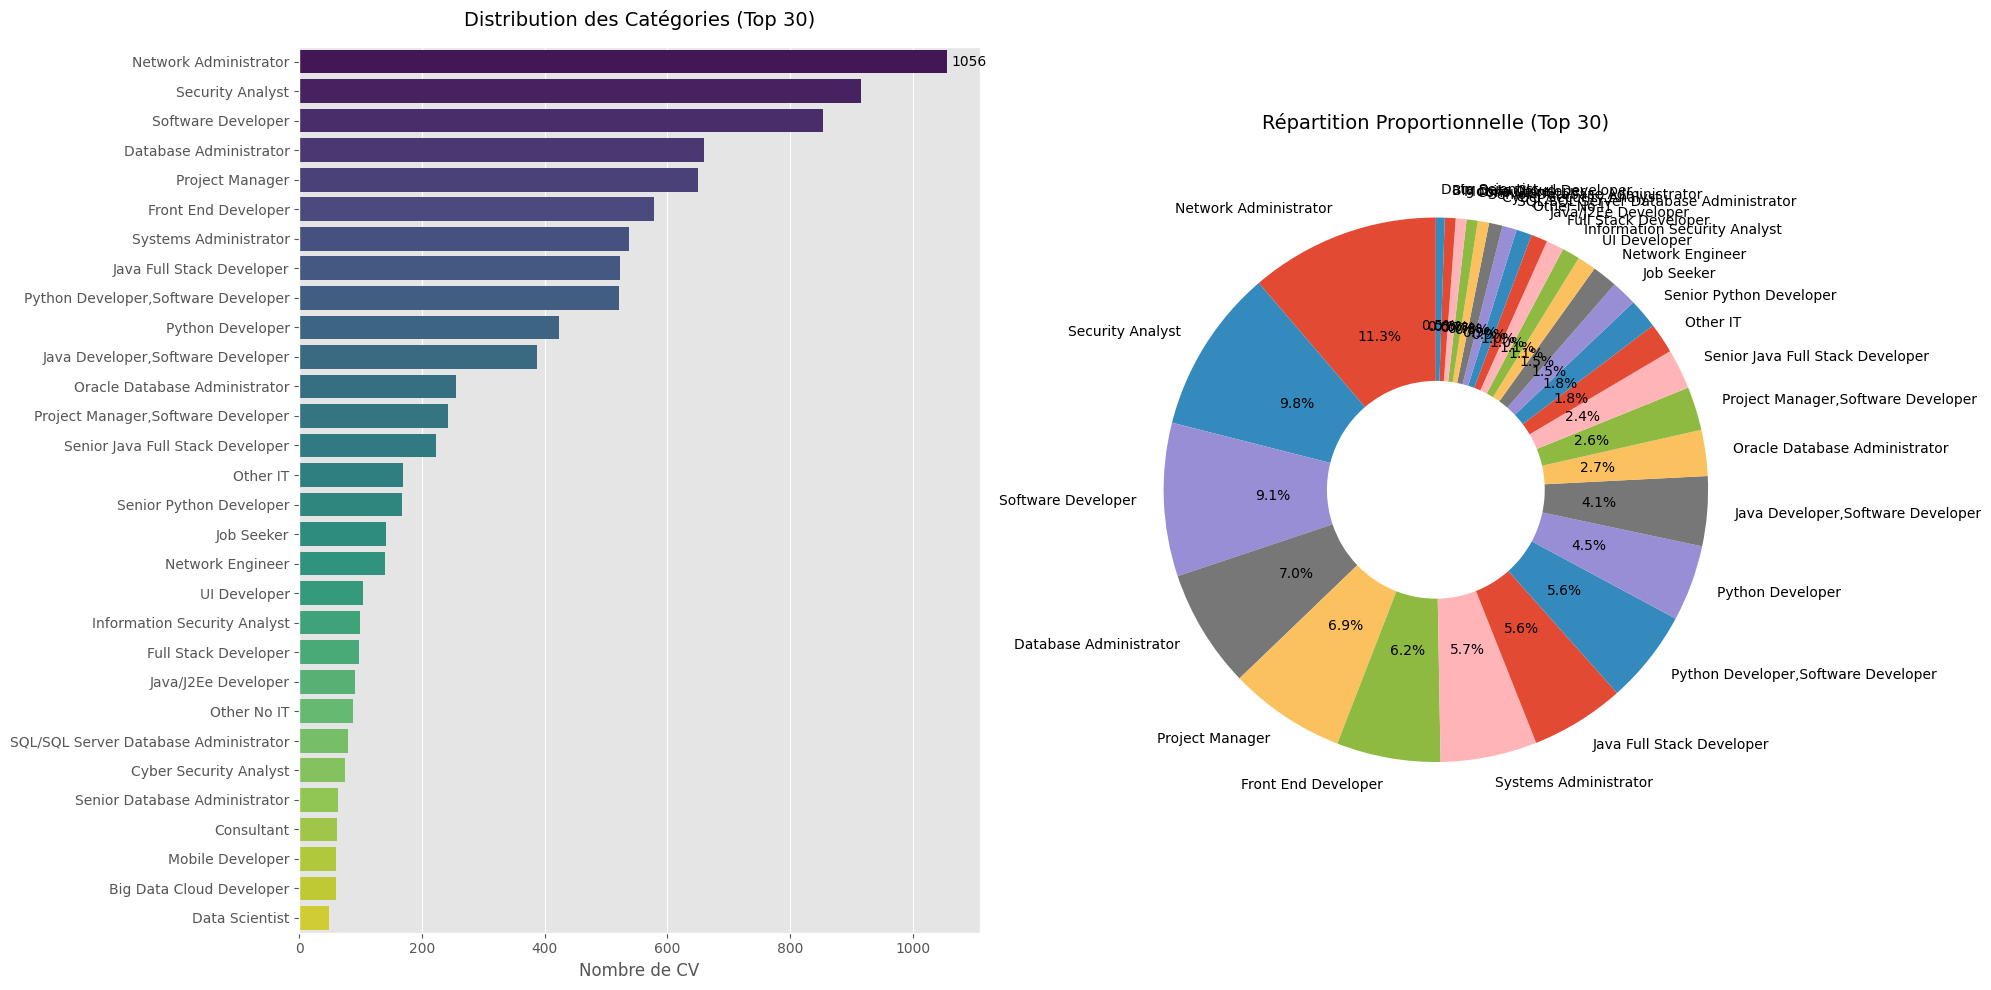

In [10]:
plot_category_distribution(cleaned_resume_dataset,'Category',30)

/tmp/ipykernel_8085/9861235.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.barplot(x=mean_by_category.head(n_categories).values,


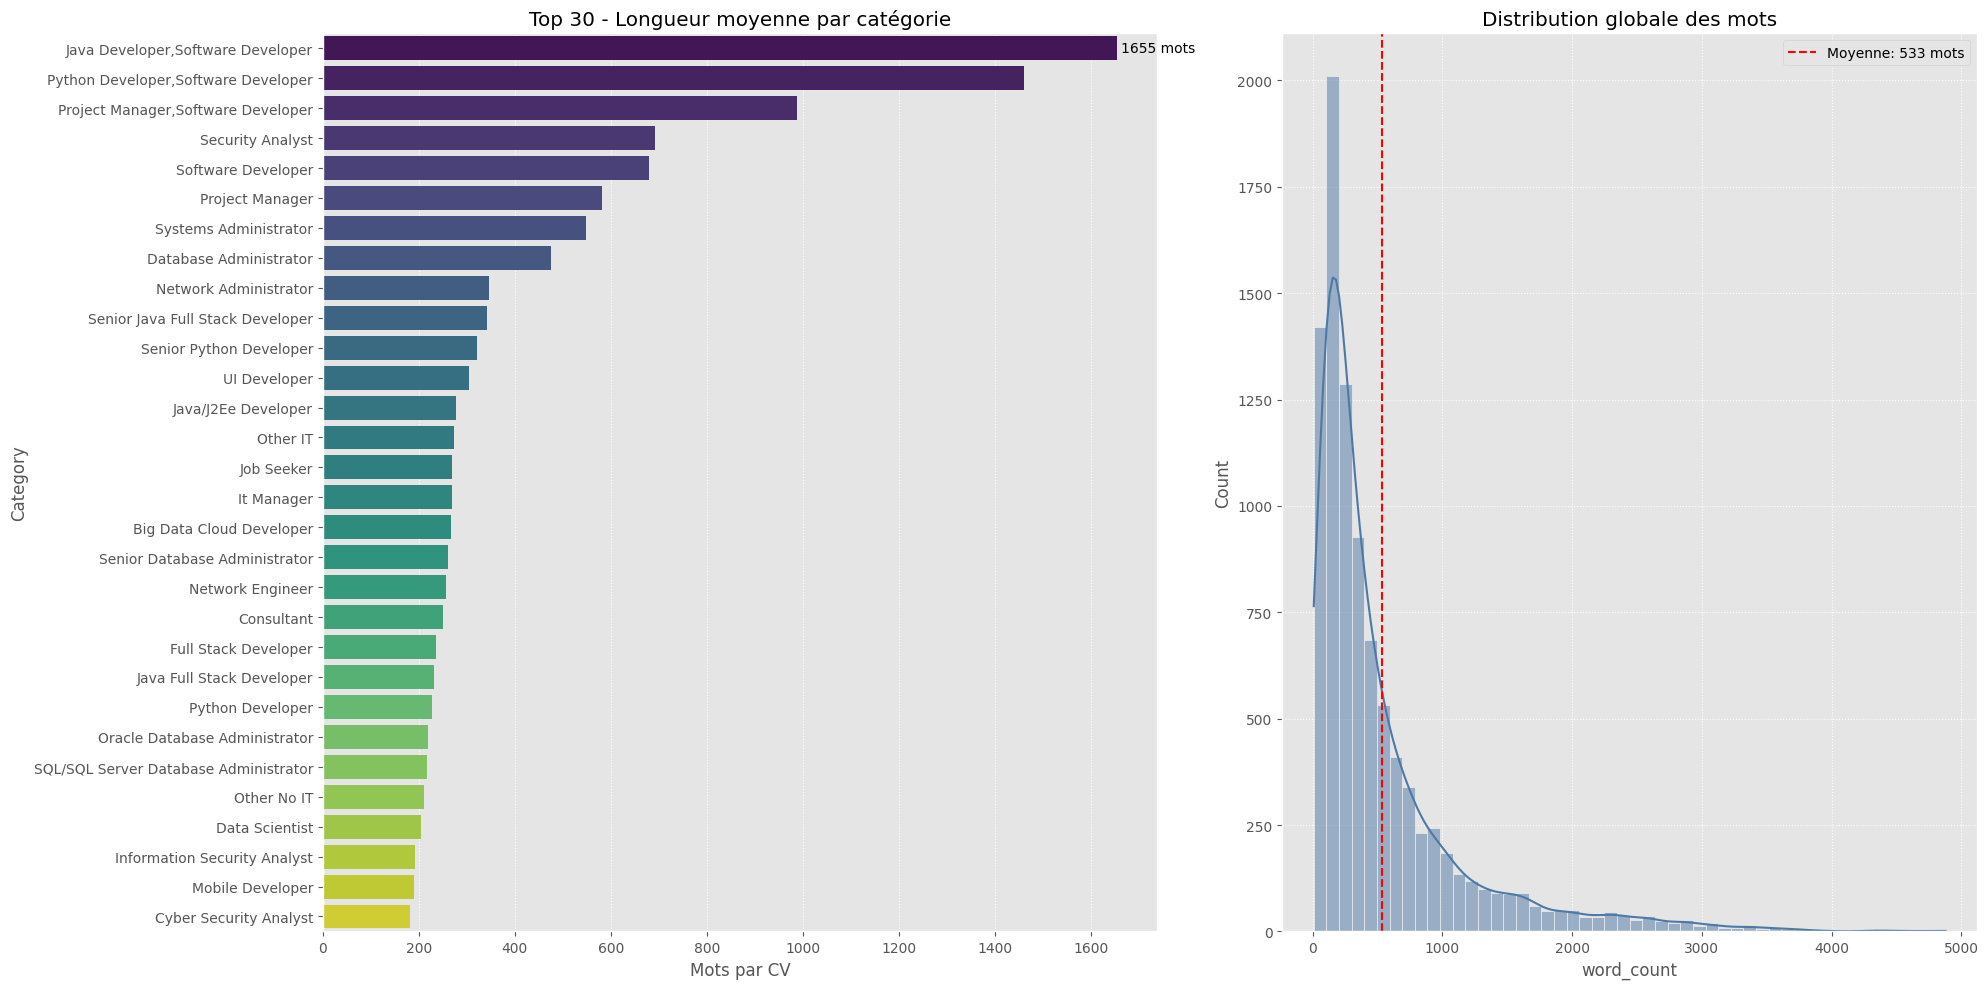

In [11]:
plot_cv_length_analysis(cleaned_resume_dataset, 30)

#### Offer

/tmp/ipykernel_8085/1699642339.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.barplot(x=top_cats.values, y=top_cats.index, palette="viridis", ax=ax1)


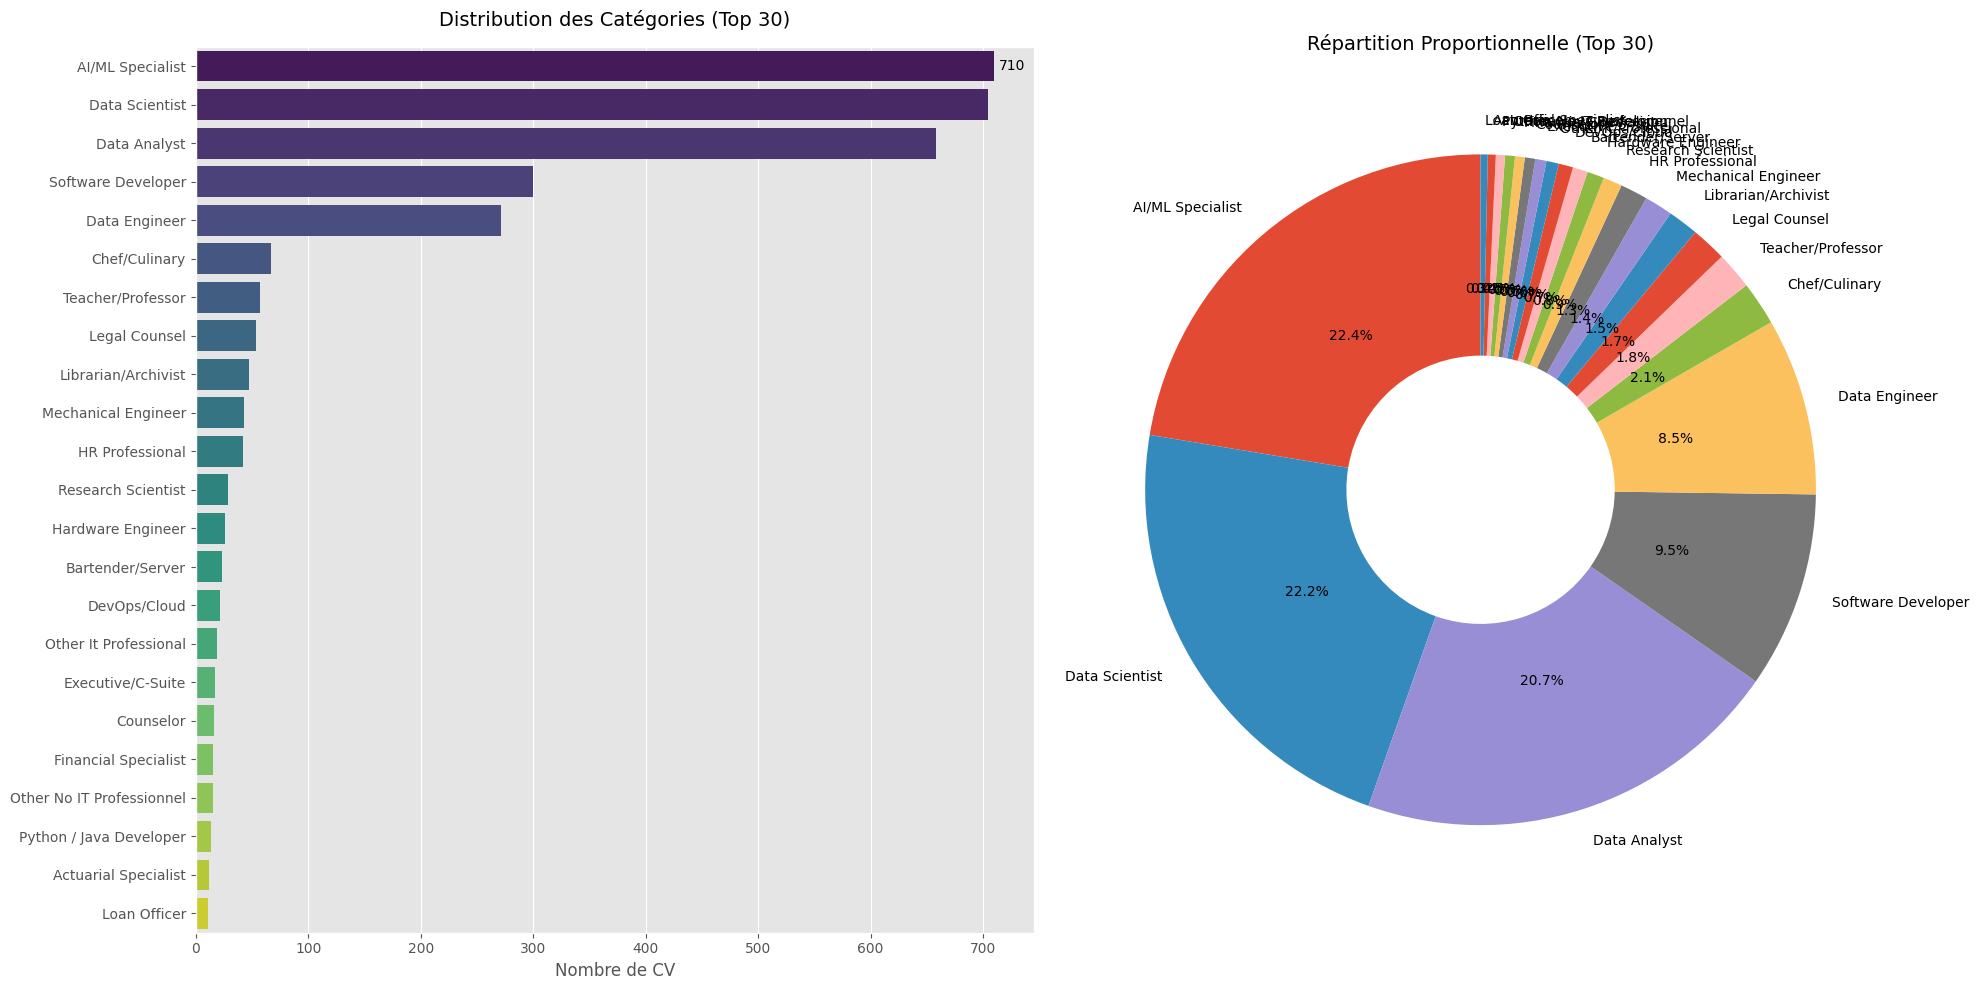

In [12]:
plot_category_distribution(cleaned_offer_dataset,'Job Title_Category',30)


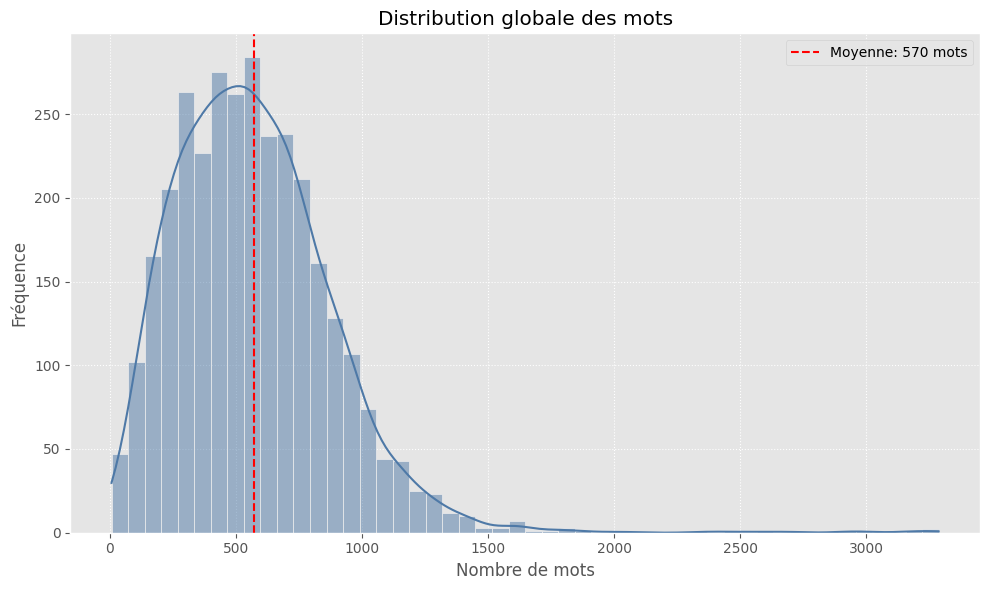

In [13]:
# 2. Distribution globale
import seaborn as sns
df = cleaned_offer_dataset.copy()
df['word_count'] = df['Job Description'].apply(lambda x: len(x.split()))
mean_by_category = df.groupby('Job Title_Category')['word_count'].mean().sort_values(ascending=False)
global_mean = df['word_count'].mean()
                      
plt.figure(figsize=(10, 6))

# Génération de l'histogramme
hist = sns.histplot(df['word_count'], bins=50, kde=True, color='#4e79a7')

# Ajout de la ligne de moyenne
plt.axvline(
    global_mean, 
    color='red', 
    linestyle='--', 
    label=f'Moyenne: {global_mean:.0f} mots'
)

# Personnalisation du graphique
plt.title('Distribution globale des mots')
plt.xlabel('Nombre de mots')
plt.ylabel('Fréquence')
plt.legend()
plt.grid(linestyle=':')

# Ajustement et affichage
plt.tight_layout()
plt.show()

In [14]:
# # import matplotlib.pyplot as plt
# from wordcloud import WordCloud
# all_descriptions_wc = ' '.join(cleaned_offer_dataset['Job Description'].astype(str).tolist())

# # Create a WordCloud object
# wordcloud = WordCloud().generate(all_descriptions_wc)

# # Display the word cloud
# plt.figure(figsize=(10, 5))
# plt.imshow(wordcloud, interpolation='bilinear')
# plt.axis("off")
# plt.title("Word Cloud of Job Descriptions")
# plt.show()

In [16]:
# import matplotlib.pyplot as plt
# from wordcloud import WordCloud
# import matplotlib.font_manager as fm

# all_descriptions_wc = ' '.join(cleaned_offer_dataset['Job Description'].astype(str).tolist())

# # font_path = "/usr/share/fonts/truetype/freefont/FreeSans.ttf"

# # Créer le nuage de mots
# wordcloud = WordCloud(
#     width=1200,
#     height=600,
#     background_color='white',
#     max_words=200,
#     collocations=False,
#     contour_width=1,
#     contour_color='steelblue'
# ).generate(all_descriptions_wc)
# # Afficher le résultat
# plt.figure(figsize=(14, 8))
# plt.imshow(wordcloud, interpolation='bilinear')
# plt.axis("off")
# plt.title("Nuage de Mots des Descriptions d'Emploi", fontsize=18, pad=20)
# plt.tight_layout(pad=1)
# plt.show()

# # Option: sauvegarder l'image
# # wordcloud.to_file("job_descriptions_wordcloud.png")

In [17]:
import plotly.express as px

all_descriptions_wc = ' '.join(cleaned_offer_dataset['Job Description'].astype(str).tolist())
freq = {}
for word in all_descriptions_wc.split():
    freq[word] = freq.get(word, 0) + 1

df = [{"word": w, "freq": f} for w, f in freq.items()]
fig = px.treemap(df, path=["word"], values="freq", title="Word Treemap")
fig.show()

In [ ]:
from pyecharts.charts import WordCloud
from pyecharts import options as opts

all_descriptions_wc = ' '.join(cleaned_offer_dataset['Job Description'].astype(str).tolist())
words = [(w, all_descriptions_wc.count(w)) for w in set(all_descriptions_wc.split())]

wc = (
    WordCloud()
    .add("", words, word_size_range=[10, 60])
    .set_global_opts(title_opts=opts.TitleOpts(title="Nuage de Mots Interactif"))
)
wc.render("wordcloud.html")
